# Projeto Integrador III – Análise de dados
## Predição de Inadimplência com Base no Perfil de Clientes de Cartão de Crédito

### Integrantes
- Hellen Karla Costa Campos Moraes de Melo 
- José Henrique Bessi Wolkers
- Kaio Soares Pacheco  
- Yasmim Luiz dos Santos  

### Descrição do Projeto

Este projeto tem como objetivo analisar dados de clientes de cartão de crédito para identificar padrões associados à inadimplência e desenvolver modelos capazes de prever o risco de não pagamento.

A análise será realizada utilizando técnicas de estatística e aprendizado de máquina, incluindo análise exploratória de dados, testes de hipóteses e modelos de classificação.

### Problema de Pesquisa

Quais características dos clientes estão mais associadas à inadimplência e é possível prever, com base nesses dados, quais clientes apresentam maior risco de não pagamento?

### Objetivo deste Notebook

Este notebook corresponde à fase de desenvolvimento e análise inicial do projeto, incluindo:

- tratamento e preparação dos dados  
- análise exploratória (EDA)  
- aplicação de testes estatísticos  
- desenvolvimento inicial de modelos de machine learning  

## Glossário das colunas do dataset 'Default of Credit Card Clients Dataset'
O dataset utilizado contém variáveis relacionadas ao perfil demográfico, histórico de pagamento e comportamento financeiro dos clientes, conforme descrito a seguir:

### ID:
Identificador único de cada cliente.

### LIMIT_BAL:
Valor do limite de crédito concedido ao cliente (em dólares taiwaneses – NT$), incluindo crédito individual e familiar/suplementar.

### SEX:
Sexo do cliente:

- 1 = masculino
- 2 = feminino

### EDUCATION:
Nível de escolaridade do cliente:
- 1 = pós-graduação
- 2 = ensino superior (graduação)
- 3 = ensino médio
- 4 = outros
- 5 = desconhecido
- 6 = desconhecido

### MARRIAGE:
Estado civil do cliente:
- 1 = casado
- 2 = solteiro
- 3 = outros

### AGE:
Idade do cliente (em anos).

### Histórico de Pagamento (PAY_X)

Representam o status de pagamento mensal do cliente:

- **PAY_0:** status de pagamento em setembro de 2005
- **PAY_2:** status de pagamento em agosto de 2005
- **PAY_3:** status de pagamento em julho de 2005
- **PAY_4:** status de pagamento em junho de 2005
- **PAY_5:** status de pagamento em maio de 2005
- **PAY_6:** status de pagamento em abril de 2005

Escala de valores:
- 1 = pagamento em dia
- 1 = atraso de 1 mês
- 2 = atraso de 2 meses
...
- 8 = atraso de 8 meses
- 9 = atraso de 9 meses ou mais

### Valores de Fatura (BILL_AMT_X)
Representam o valor da fatura do cartão em cada mês (em NT$):
- BILL_AMT1: setembro de 2005
- BILL_AMT2: agosto de 2005
- BILL_AMT3: julho de 2005
- BILL_AMT4: junho de 2005
- BILL_AMT5: maio de 2005
- BILL_AMT6: abril de 2005

### Valores de Pagamento (PAY_AMT_X)
Representam o valor pago pelo cliente em cada mês (em NT$):
- PAY_AMT1: pagamento em setembro de 2005
- PAY_AMT2: pagamento em agosto de 2005
- PAY_AMT3: pagamento em julho de 2005
- PAY_AMT4: pagamento em junho de 2005
- PAY_AMT5: pagamento em maio de 2005
- PAY_AMT6: pagamento em abril de 2005

### **Variável Alvo**

**default.payment.next.month:**
Indica se o cliente foi inadimplente no mês seguinte:

- 1 = sim (inadimplente)
- 0 = não (adimplente)

In [1]:
### Dataset Utilizado
Default of Credit Card Clients Dataset

SyntaxError: invalid syntax (1795572566.py, line 2)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
df = pd.read_csv('UCI_Credit_Card.csv')
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


### Estrutura dos dados

In [4]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [6]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


### Tratamento de Dados

Inicialmente, foi realizada a verificação de valores nulos no dataset para garantir a qualidade dos dados antes das análises.

In [7]:
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

Não foram identificados valores nulos na base.


In [8]:
df['EDUCATION'].value_counts()

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

In [9]:
df['EDUCATION'] = df['EDUCATION'].replace([0,5,6],4)

In [10]:
df['EDUCATION'].value_counts()

EDUCATION
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64

In [11]:
df['MARRIAGE'].value_counts()

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

Também foram verificadas inconsistências em variáveis categóricas, como EDUCATION e MARRIAGE.

### Criação de novas variáveis

In [12]:
df['divida_total'] = df[['BILL_AMT1','BILL_AMT2','BILL_AMT3',
                         'BILL_AMT4','BILL_AMT5','BILL_AMT6']].sum(axis=1)

df['pagamento_total'] = df[['PAY_AMT1','PAY_AMT2','PAY_AMT3',
                            'PAY_AMT4','PAY_AMT5','PAY_AMT6']].sum(axis=1)

### Distribuição da variável alvo

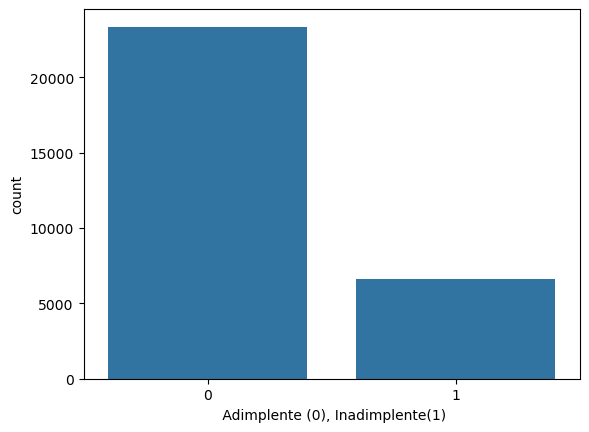

In [13]:
sns.countplot(x='default.payment.next.month',data=df)
plt.xlabel(" Adimplente (0), Inadimplente(1)")
plt.show()

O gráfico indica que há uma distribuição de adimplentes maior do que de inadimplentes

### Comparação do limite de crédito entre adimplentes e inadimplentes

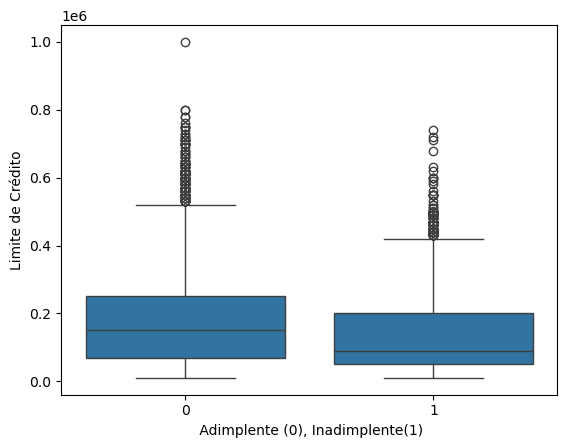

In [14]:
sns.boxplot(x='default.payment.next.month', y='LIMIT_BAL', data=df)
plt.xlabel(" Adimplente (0), Inadimplente(1)")
plt.ylabel("Limite de Crédito")
plt.show()

Pode se observar que clientes inadimplentes tendem a apresentar limites de créditos menores em comparação aos adimplentes, sugerindo que o limite de crédito pode estar relacionado ao risco de inadimplência.

### Relação entre idade e Inadimplência

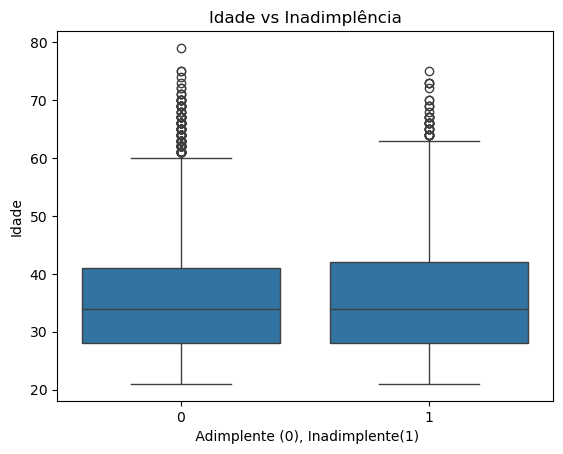

In [15]:
sns.boxplot(x='default.payment.next.month', y='AGE', data=df)
plt.title("Idade vs Inadimplência")
plt.xlabel(" Adimplente (0), Inadimplente(1)")
plt.ylabel("Idade")
plt.show()

A distribuição de idade entre os grupos não apresenta uma diferença muito grande, indicando que a idade pode não ser um fator determinante isolado para inadimplência.

### Relação entre histórico de pagamento e inadimplência

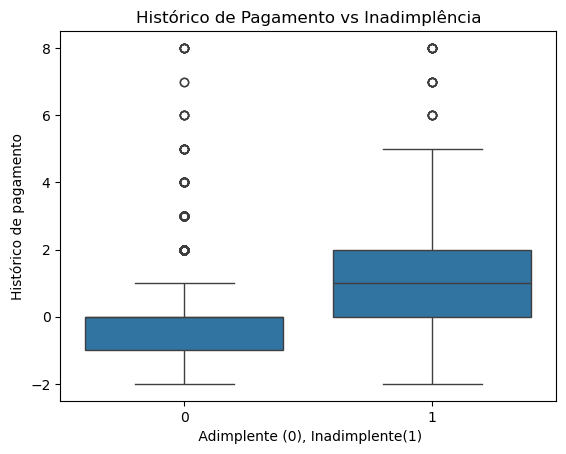

In [16]:
sns.boxplot(x='default.payment.next.month', y='PAY_0', data=df)
plt.title("Histórico de Pagamento vs Inadimplência")
plt.xlabel(" Adimplente (0), Inadimplente(1)")
plt.ylabel("Histórico de pagamento")
plt.show()

O grupo inadimplente apresenta maior histórico de atrasos nos pagamentos, sugerindo que esse é um dos fatores mais relevantes para prever inadimplência.

### Relação entre a dívida total e a inadimplência

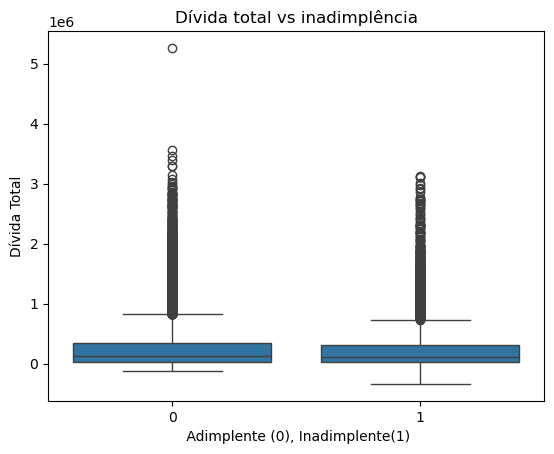

In [17]:
sns.boxplot(x='default.payment.next.month', y="divida_total", data=df)
plt.title("Dívida total vs inadimplência")
plt.xlabel(" Adimplente (0), Inadimplente(1)")
plt.ylabel("Dívida Total")
plt.show()

Observa-se que clientes inadimplentes apresentam volume maior de dívida acumulada, reforçando que a responsabilidade financeira está relacionada ao risco de inadimplência.

### Correlação entre os fatores analisados

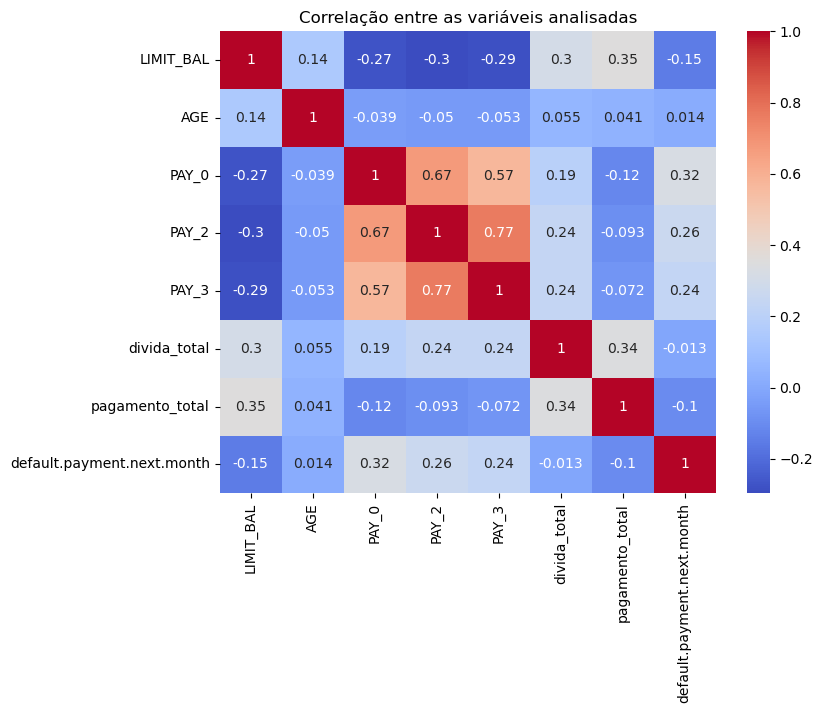

In [18]:
relacao = ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'divida_total', 'pagamento_total','default.payment.next.month']
corr = df[relacao].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlação entre as variáveis analisadas")
plt.show()

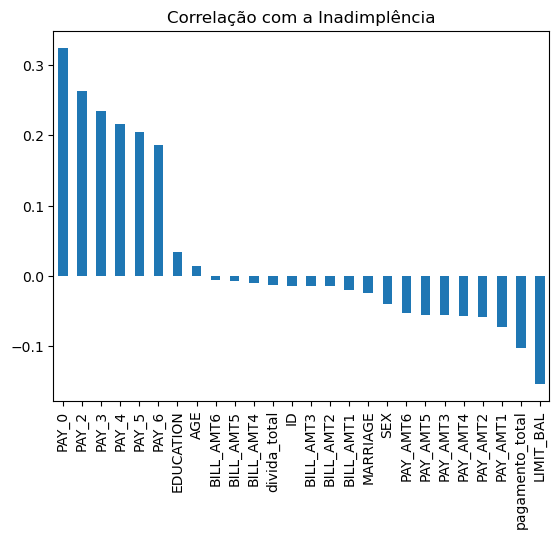

In [19]:
corr_target = df.corr()['default.payment.next.month'].sort_values(ascending=False)
corr_target.drop('default.payment.next.month').plot(kind='bar')
plt.title("Correlação com a Inadimplência")
plt.show()


Observa-se que variáveis relacionadas ao histórico de pagamento apresentam maior correlação com a inadimplência, indicando que atrasos anteriores são fortes indicadores de risco.
Variáveis como limite de crédito e idade apresentam menor correlação isolada, sugerindo que seu impacto pode ocorrer em conjunto com outros fatores.

## Modelagem Preditiva - José
Meu objetivo vai ser criar modelos que consigam aprender com os dados históricos e me dizer se um cliente tem chance de ficar inadimplente ou não no mês que vem.

### Preparando os dados

Vou fazer a sepração das características dos clientes (X) para o que a gente quer prever (y), e dividir em teste.

In [36]:
X = df.drop(['ID', 'default.payment.next.month'], axis=1)
y = df['default.payment.next.month']

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_treino_escalado = scaler.fit_transform(X_treino)
X_teste_escalado = scaler.transform(X_teste)

### 1. Regressão Logística

Para problemas de classificação (sim ou não).

In [38]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

modelo_logistico = LogisticRegression(max_iter=1000) # Treinamento
modelo_logistico.fit(X_treino_escalado, y_treino)

y_predito_log = modelo_logistico.predict(X_teste_escalado) # Realização de previsões

print("Relatório de Classificação | Regressão Logística:")
print(classification_report(y_teste, y_predito_log))
print(f"Acurácia: {accuracy_score(y_teste, y_predito_log):.2f}")

Relatório de Classificação | Regressão Logística:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      7009
           1       0.70      0.24      0.35      1991

    accuracy                           0.81      9000
   macro avg       0.76      0.60      0.62      9000
weighted avg       0.79      0.81      0.77      9000

Acurácia: 0.81


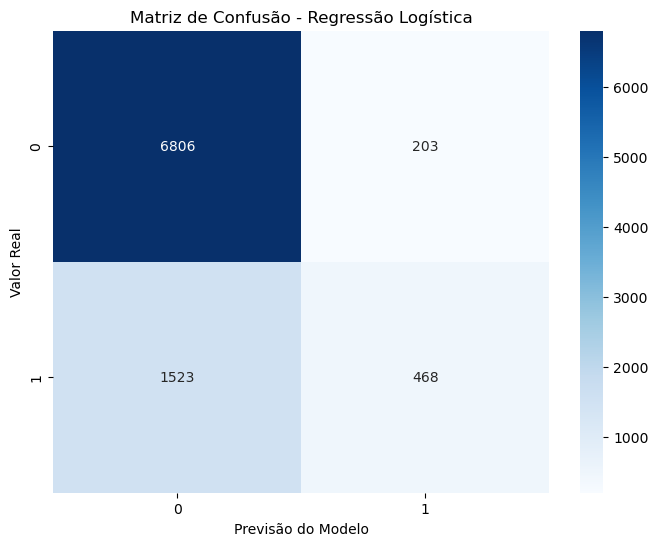

In [40]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_teste, y_predito_log), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Regressão Logística')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real')
plt.show()

### 2. Árvore de Decisão



In [43]:
modelo_arvore = DecisionTreeClassifier(max_depth=5, random_state=42) #Treinamento
modelo_arvore.fit(X_treino, y_treino)

y_predito_arvore = modelo_arvore.predict(X_teste) #Previsões

print("Relatório de Classificação - Árvore de Decisão:")
print(classification_report(y_teste, y_predito_arvore))
print(f"Acurácia: {accuracy_score(y_teste, y_predito_arvore):.2f}")

Relatório de Classificação - Árvore de Decisão:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      7009
           1       0.67      0.35      0.46      1991

    accuracy                           0.82      9000
   macro avg       0.75      0.65      0.67      9000
weighted avg       0.80      0.82      0.79      9000

Acurácia: 0.82


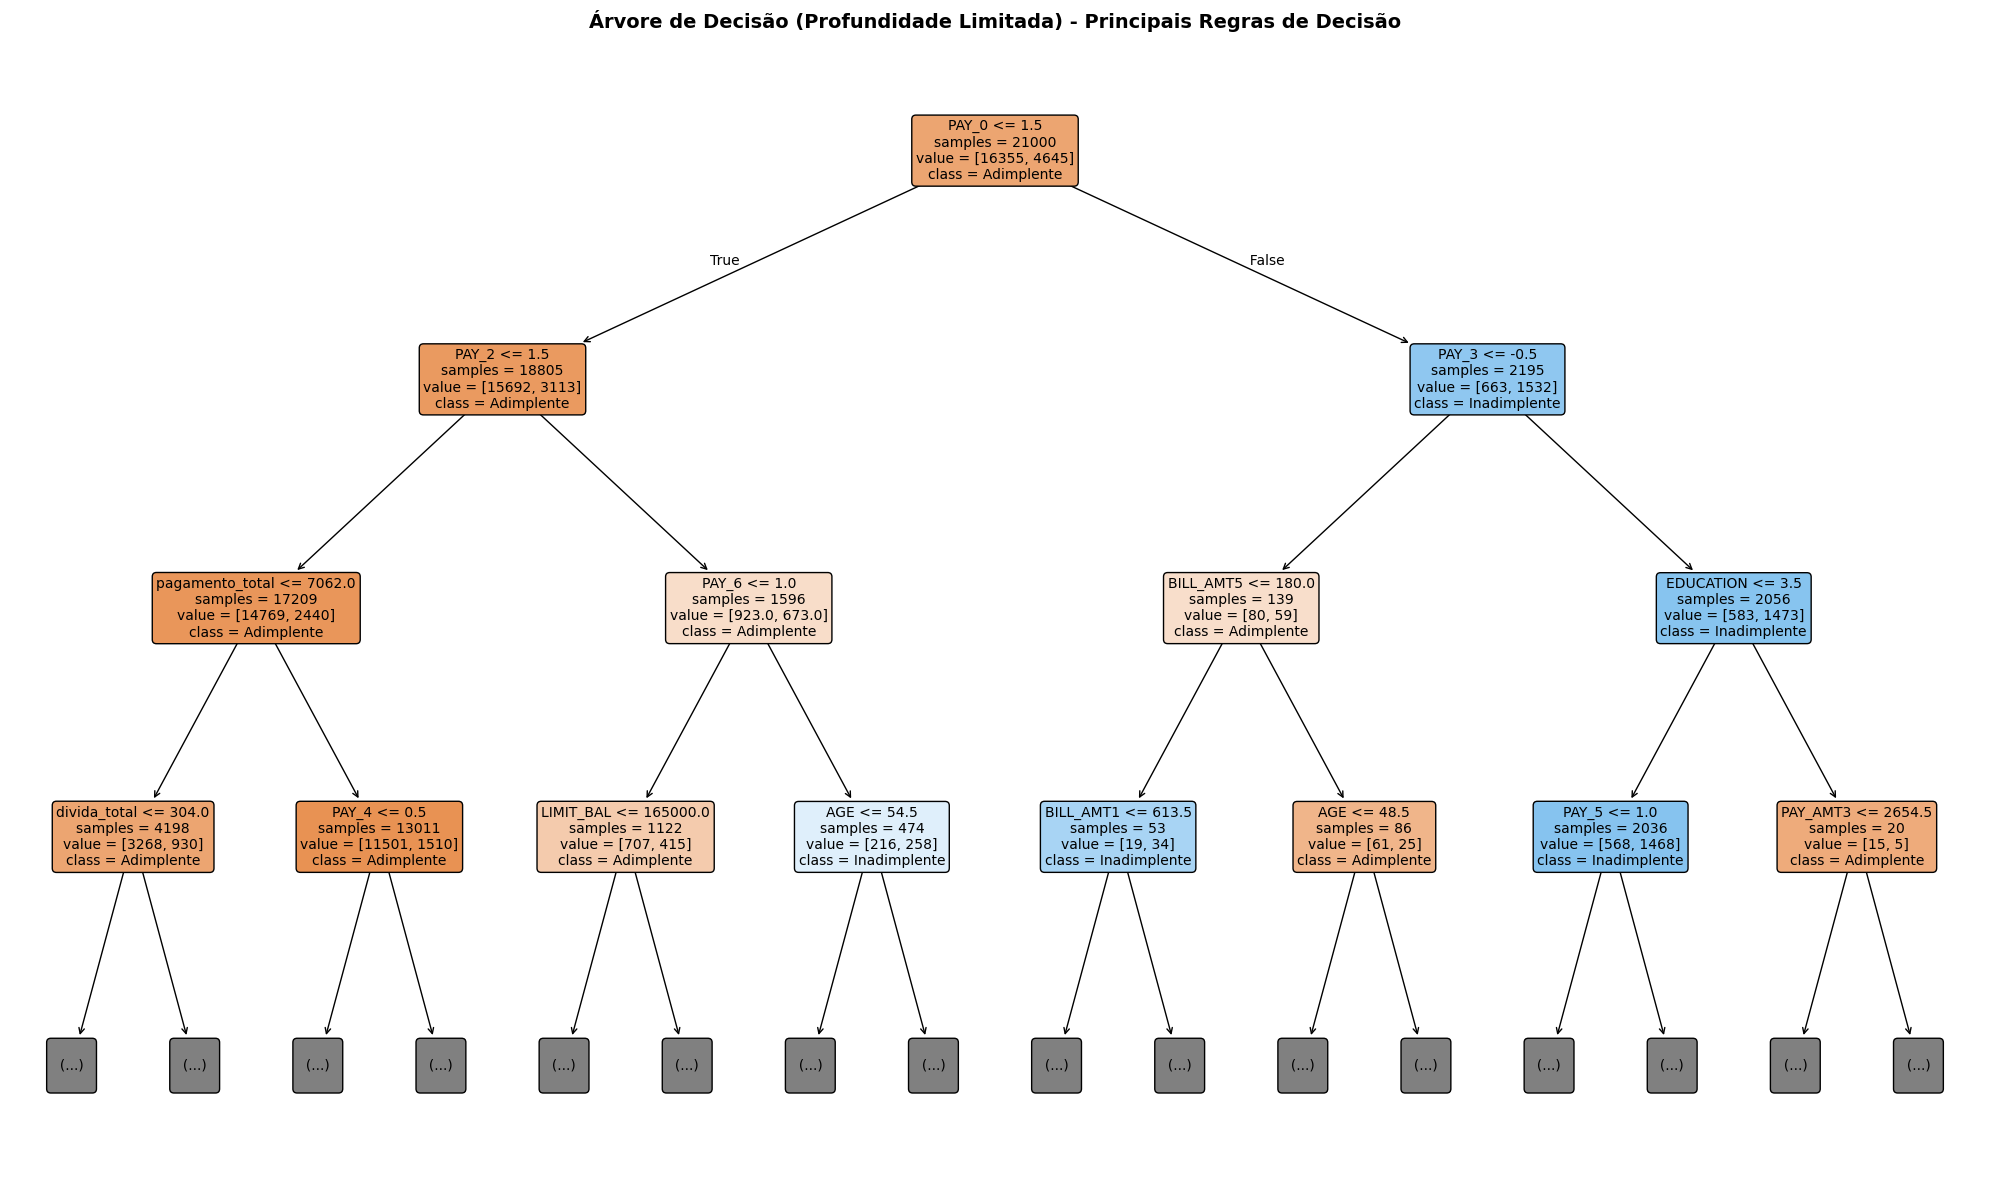

In [33]:
plt.figure(figsize=(20, 12))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=['Adimplente', 'Inadimplente'],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3,  # limitei a profundida
    proportion=False,
    impurity=False  # OculteiGini
)

plt.title('Árvore de Decisão (Profundidade Limitada) - Principais Regras de Decisão', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()